# 45 — Combine IMA and SA fallback into final Market RWA

Join eligible IMA desks and ineligible SA desks without counting a position twice.

The full-book SA result remains visible for comparison. Only the aggregate SA charge for fallback desks enters final capital alongside eligible-desk IMA capital and any amber surcharge.

This step uses: IMA eligible capital, amber surcharge, SA fallback capital and full-book SA benchmark.

It produces: Final FRTB market-risk capital and Market RWA in INR.

> Basel norm applied: MAR33.43 aggregates eligible IMA desks with SA fallback; MAR33.46 multiplies capital by 12.5.

$$K_{Market}=IMA_{G,A}+PLA\ surcharge+C_U,\qquad RWA_{Market}=12.5K_{Market}$$

Synthetic inputs are labelled directly in the displayed data. Basel regulatory parameters are loaded separately from versioned configuration.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from frtb_engine.notebook_tools import INR_CRORE, configure_notebooks, crore_table, draw_flow, heatmap

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_ima_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
MANIFEST = json.loads((RUN / 'run_manifest.json').read_text(encoding='utf-8'))
STAGES = {row['stage']: ROOT / row['path'] for row in MANIFEST['artifacts']}
SUMMARY = json.loads((RUN / '27_combined_capital_summary.json').read_text(encoding='utf-8'))

def stage(name):
    return pd.read_csv(STAGES[name])

def money(value):
    return f"INR {float(value) / INR_CRORE:,.2f} crore"

print(f'IMA calculation run used: {RUN_ID}')
print('Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled')

IMA calculation run used: IMA_20260908T033903126517Z
Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled


In [2]:
desk=stage('25_desk_capital_summary')
capital_columns=['sa_capital_inr','ima_component_inr','amber_surcharge_inr','sa_fallback_component_inr','final_capital_treatment_inr']
display(crore_table(desk[['desk','final_treatment',*capital_columns]],capital_columns))
print(f"Eligible IMA before surcharge {money(SUMMARY['ima_eligible_capital_before_surcharge_inr'])} + amber surcharge {money(SUMMARY['pla_amber_surcharge_inr'])} + SA fallback {money(SUMMARY['sa_fallback_capital_inr'])} = {money(SUMMARY['final_frtb_market_risk_capital_inr'])}")
print(f"Market RWA = 12.5 × capital = {money(SUMMARY['market_rwa_inr'])}")

,desk,final_treatment,Sa Capital (INR crore),Ima Component (INR crore),Amber Surcharge (INR crore),Sa Fallback Component (INR crore),Final Capital Treatment (INR crore)
0,Commodity,IMA_GREEN,35.7561,27.9900,0.0000,0.0000,27.9900
1,Credit,IMA_GREEN,26.7431,20.9346,0.0000,0.0000,20.9346
2,Equity,IMA_GREEN,36.4942,28.5678,0.0000,0.0000,28.5678
3,FX,IMA_GREEN,5.5035,4.3081,0.0000,0.0000,4.3081
4,Rates,IMA_GREEN,8.8352,6.9162,0.0000,0.0000,6.9162
5,Residual Risk,SA_FALLBACK,0.0800,0.0000,0.0000,0.0800,0.0800


Eligible IMA before surcharge INR 88.72 crore + amber surcharge INR 0.00 crore + SA fallback INR 0.08 crore = INR 88.80 crore
Market RWA = 12.5 × capital = INR 1,109.96 crore


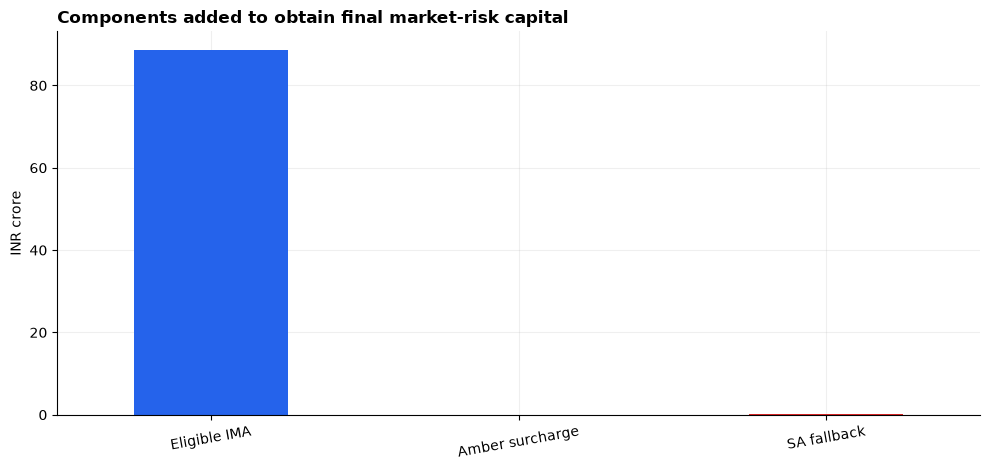

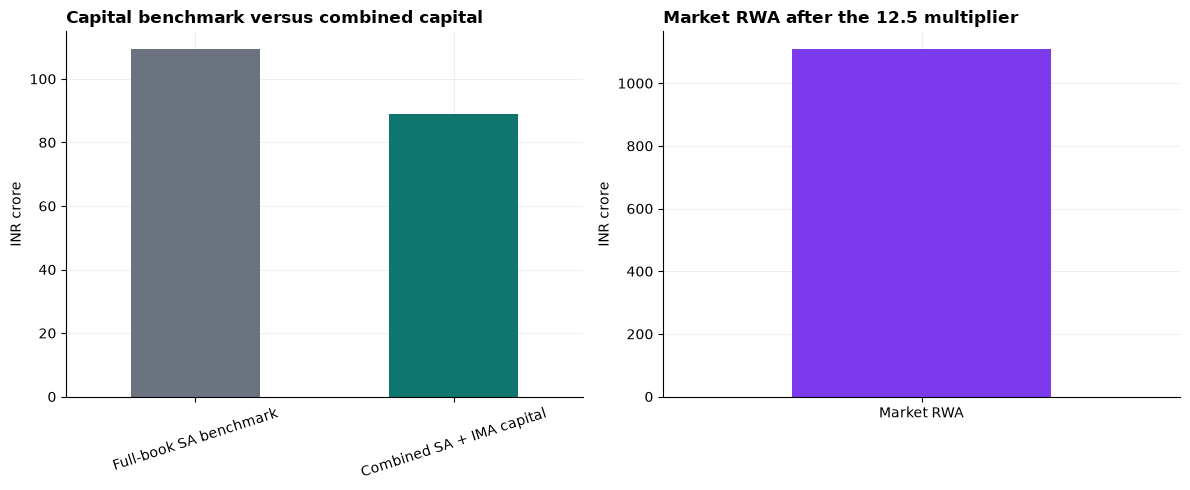

In [3]:
parts=pd.Series({'Eligible IMA':SUMMARY['ima_eligible_capital_before_surcharge_inr'],'Amber surcharge':SUMMARY['pla_amber_surcharge_inr'],'SA fallback':SUMMARY['sa_fallback_capital_inr']})/INR_CRORE; ax=parts.plot(kind='bar',color=['#2563EB','#F59E0B','#DC2626']); ax.set_ylabel('INR crore'); ax.set_title('Components added to obtain final market-risk capital',loc='left',weight='bold'); ax.tick_params(axis='x',rotation=10); plt.tight_layout(); plt.show()
capital_comparison=pd.Series({'Full-book SA benchmark':SUMMARY['full_book_sa_capital_inr'],'Combined SA + IMA capital':SUMMARY['final_frtb_market_risk_capital_inr']})/INR_CRORE; fig,axes=plt.subplots(1,2,figsize=(12,5)); capital_comparison.plot(kind='bar',ax=axes[0],color=['#6B7280','#0F766E']); axes[0].set_ylabel('INR crore'); axes[0].set_title('Capital benchmark versus combined capital',loc='left',weight='bold'); axes[0].tick_params(axis='x',rotation=18); pd.Series({'Market RWA':SUMMARY['market_rwa_inr']/INR_CRORE}).plot(kind='bar',ax=axes[1],color='#7C3AED'); axes[1].set_ylabel('INR crore'); axes[1].set_title('Market RWA after the 12.5 multiplier',loc='left',weight='bold'); axes[1].tick_params(axis='x',rotation=0); plt.tight_layout(); plt.show()

The first chart shows the three amounts added to obtain final market-risk capital: eligible-desk IMA, the amber surcharge and SA fallback. The second visual uses separate panels because capital and RWA have different scales. The left panel compares the full-book SA benchmark with combined SA–IMA capital; the right panel shows Market RWA, which equals combined capital multiplied by 12.5.